**Module 2**

---

**Activity 1**

The central Limit theorem

The scaled sum of a sequence of i.i.d. random variables with finite mean and variance converges in distribution to the normal distribution.

Gaussian distributions appear in IQ distribution, GS of SHM in QM, transverse intensity of particle beam core, number of decay events with high average decay rate, etc.

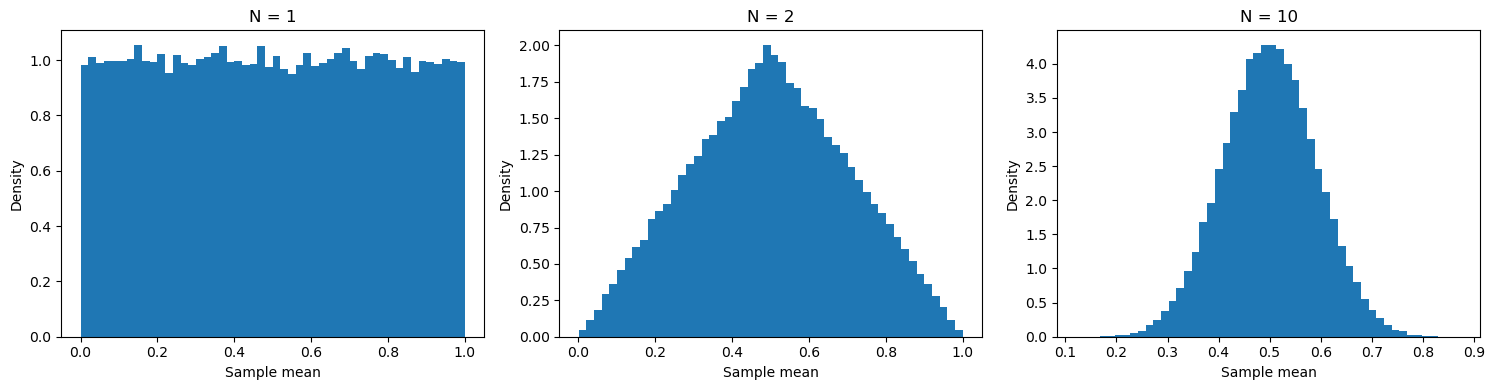

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import time

N_sample = 100000
N_variable = [1, 2, 10]

plt.figure(figsize=(15, 4))

for i, N in enumerate(N_variable, 1):
    # Generate samples
    samples = np.random.uniform(0, 1, size=(N_sample, N))
    x = samples.mean(axis=1)
    
    # Plot
    plt.subplot(1, 3, i)
    plt.hist(x, bins=50, density=True)
    plt.title(f"N = {N}")
    plt.xlabel("Sample mean")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


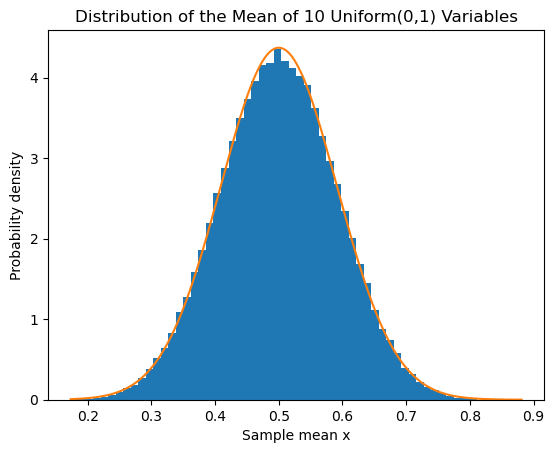

In [161]:
# ----- Parameters -----
Nvarible = 10     # number of Uniform(0,1) variables
Nsample = 100000  # number of trials (how many means we compute)

# ----- Generate data -----
# Each row contains N independent Uniform(0,1) random variables
samples = np.random.uniform(0, 1, size=(Nsample, Nvarible))

# Compute the mean of each row
x = samples.mean(axis=1)

# ----- Plot the distribution of the mean -----
plt.figure()
plt.hist(x, bins=60, density=True)

# ----- Gaussian prediction -----
mu = 0.5
sigma = np.sqrt(1/(12*Nvarible))

x_grid = np.linspace(min(x), max(x), 500)
gaussian_pdf = (1/(sigma*np.sqrt(2*np.pi))* np.exp(-(x_grid - mu)**2 / (2*sigma**2)))
plt.plot(x_grid, gaussian_pdf)

plt.title(f"Distribution of the Mean of {Nvarible} Uniform(0,1) Variables")
plt.xlabel("Sample mean x")
plt.ylabel("Probability density")
plt.show()


**Activity 3**
## Gaussian Contours and Mahalanobis Distance
Constant-density contours satisfy:

$$
(\mathbf{x}-\mu)^T \Sigma^{-1} (\mathbf{x}-\mu) = Q
$$

The quantity $Q$ is the squared Mahalanobis distance. Contours of constant PDF correspond to constant $Q$.  

Probability inside a contour is:

$$
P(\chi^2_d \le Q) = F_{\chi^2_d}(Q)
$$

where $F_{\chi^2_d}$ is the cumulative distribution function of the χ² distribution with $d$ degrees of freedom.


(1000, 2)


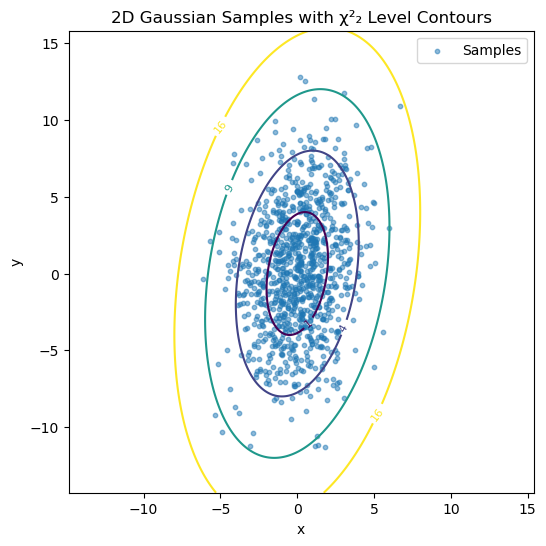

5.431885462677146e-13 0.02054274501162333


In [162]:
mean = np.array([0, 0])
cov = np.array([[4, 2],
                [2, 16]])


N = 1000
samples = np.random.multivariate_normal(mean, cov, size=N)
print(samples.shape)  # Check shapes (N, d = 2)

plt.figure(figsize=(6, 6))
x = samples[:, 0]
y = samples[:, 1]
plt.scatter(x, y, s=10, alpha=0.5, label="Samples")


x_grid = np.linspace(x.min() - 3, x.max() + 3, 200)
y_grid = np.linspace(y.min() - 3, y.max() + 3, 200)
X, Y = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X, Y))

diff = pos - mean
cov_inv = np.linalg.inv(cov)
Q = np.einsum('...i,ij,...j->...', diff, cov_inv, diff) # Einstein summation # Q[i,j] = (x - μ)^T Σ⁻¹ (x - μ)

# Contours of constant Mahalanobis distance
levels = [1, 4, 9, 16] # Q = χ²₂
contours = plt.contour(X, Y, Q, levels=levels)
plt.clabel(contours, inline=True, fontsize=8)


plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.title("2D Gaussian Samples with χ²₂ Level Contours")
plt.legend()
plt.show()


from scipy.stats import multivariate_normal

# Multivariate Gaussian PDF
rv = multivariate_normal(mean, cov)
Z = rv.pdf(pos) # Z = p(X,Y)
print(Z.min(),Z.max())

# Contours of constant PDF
# contours = plt.contour(X, Y, Z, levels=6)  # levels = sth equivalent to levels = np.linspace(Z.min(), Z.max(), sth)
# plt.clabel(contours, inline=True, fontsize=8)


**Activity 5**
## Maximum Likelihood Estimation (MLE)

Given a dataset:

$$
X = \{X_1, \dots, X_N\}, \quad X_n \in \mathbb{R}^d
$$

### Mean Estimate

$$
\hat{\mu}
= \frac{1}{N}
\sum_{n=1}^{N}
X_n
$$

### Covariance Estimate

$$
\hat{\Sigma}
= \frac{1}{N}
\sum_{n=1}^{N}
(X_n - \hat{\mu})
(X_n - \hat{\mu})^T
$$

The MLE uses $\frac{1}{N}$ (not $\frac{1}{N-1}$).

---

## Sequential Estimator

The sequential estimator updates the parameters one observation at a time. This allows updating the mean  and covariance without storing previous data.

After observing $x_{n+1}$, the mean update is

$$
\mu_{n+1}
= \mu_n + \delta_{n+1}
$$

where
$$
\delta_{n+1} = \frac{x_{n+1} - \mu_n}{n+1}
$$

The MLE covariance updates as:

$$
\Sigma_{n+1}
= \frac{n}{n+1}\Sigma_n
+ n\delta_{n+1}\left(\delta_{n+1}\right)^T
$$


In [163]:
d = 2
mu_mle = np.mean(samples, axis=0)

# Center data
X_centered = samples - mu_mle   # sample == X

# Compute covariance using 1/N (MLE)
sigma_mle = (X_centered.T @ X_centered) / N
sigma_unbiased = sigma_mle * N / (N - 1)

print("True Mean:\n", mean)
print("True Covariance:\n", cov)

print("\nMLE Mean:\n", mu_mle)
print("MLE Covariance:\n", sigma_mle)
print("Unbiased Covariance:\n", sigma_unbiased)

# -------------------------------------------------
# Sequential Estimator
# -------------------------------------------------

# Initialize
mu_seq = np.zeros(d)
Sigma_seq = np.zeros((d, d))

for n in range(N): # n starts from 0
    x = samples[n]
    delta = (x - mu_seq) / (n + 1)
    
    # Update mean
    mu_seq = mu_seq + delta
    
    # Update MLE covariance
    Sigma_seq = Sigma_seq * n/(n+1) + n * np.outer(delta, delta)

print("\nSequential Mean:\n", mu_seq)
print("Sequential Covariance:\n", Sigma_seq)

True Mean:
 [0 0]
True Covariance:
 [[ 4  2]
 [ 2 16]]

MLE Mean:
 [0.07801943 0.26062355]
MLE Covariance:
 [[ 3.78160674  1.5340182 ]
 [ 1.5340182  16.28640529]]
Unbiased Covariance:
 [[ 3.78539214  1.53555375]
 [ 1.53555375 16.302708  ]]

Sequential Mean:
 [0.07801943 0.26062355]
Sequential Covariance:
 [[ 3.78160674  1.5340182 ]
 [ 1.5340182  16.28640529]]


**Activity 6**
### Log-Likelihood function of sampling 1D Gaussian

Suppose we have $N$ independent samples from a 1D Gaussian $X_n \sim \mathcal{N}(\mu_{\rm true}, \sigma^2)$.
The likelihood function is:
$$
P(X_1, \dots, X_N \mid \mu, \sigma^2)
= \prod_{n=1}^{N} \frac{1}{\sqrt{2 \pi \sigma^2}} 
\exp\Big[-\frac{(X_n - \mu)^2}{2\sigma^2}\Big]
$$

Taking the logarithm gives:

$$
\log P(X_1, \dots, X_N \mid \mu, \sigma^2) = - \frac{1}{2\sigma^2} \sum_{n=1}^{N} (X_n - \mu)^2
-\frac{N}{2} \log(\sigma^2) -\frac{N}{2} \log(2\pi)
$$

### Variance of the Sample Mean

Because the samples are independent:
$$
\text{Var}(\hat{\mu}) = \text{Var}\Big(\frac{1}{N} \sum_{n=1}^{N} X_n\Big)
= \frac{1}{N^2} \sum_{n=1}^{N} \text{Var}(X_n)
= \frac{\sigma^2}{N}
$$

So the parameter uncertainty (std of $\mu$) scales as $1/\sqrt{N}$. And the graph confirms that the width of likelihood peak narrows as N increases.


N = 20
Theoretical std of MLE (σ/√N): 0.3354
----------------------------------------
N = 100
Theoretical std of MLE (σ/√N): 0.1500
----------------------------------------
N = 1000
Theoretical std of MLE (σ/√N): 0.0474
----------------------------------------


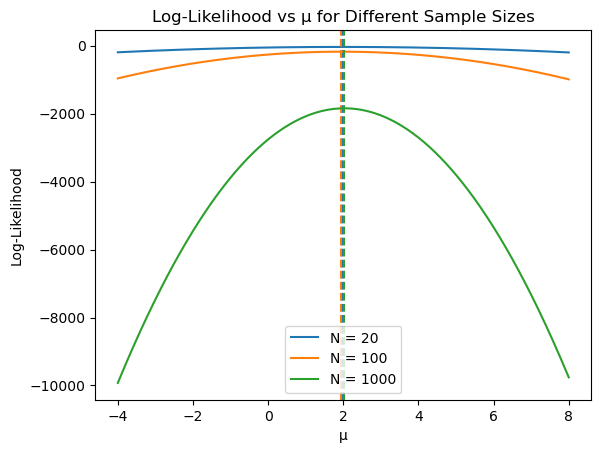

In [168]:
true_mu = 2.0
sigma = 1.5   # known standard deviation

# Compute log-likelihood over grid
def log_likelihood(data, mu, sigma):
    N = len(data)
    return -N/2 * np.log(2*np.pi*sigma**2) \
           - np.sum((data[:, None] - mu)**2, axis=0) / (2*sigma**2)

mu_grid = np.linspace(true_mu - 4*sigma,
                      true_mu + 4*sigma,
                      500)

def Gaus1D_mle(samples):
    samples = np.asarray(samples)
    N = len(samples)

    mu_mle = np.mean(samples)
    sigmaSq_mle = np.sum((samples - mu_mle)**2) / N

    return mu_mle, sigmaSq_mle

Ns = [20, 100, 1000]

plt.figure()

for N in Ns:
    data = np.random.normal(true_mu, sigma, size=N)
    
    ll = log_likelihood(data, mu_grid, sigma)

    mu_mle, sigmaSq_mle = Gaus1D_mle(data)

    # Theoretical uncertainty
    mu_std_theory = sigma / np.sqrt(N)

    print(f"N = {N}")
    print(f"Theoretical std of MLE (σ/√N): {mu_std_theory:.4f}")
    print("-" * 40)

    # likelihood curve
    line, = plt.plot(mu_grid, ll, label=f"N = {N}")  # note the comma
    color = line.get_color()  # capture the color used

    # Mark MLE
    plt.axvline(mu_mle, linestyle='--', color=color)
    # plt.axvline(mu_mle + mu_std_theory, linestyle=':')
    # plt.axvline(mu_mle - mu_std_theory, linestyle=':')

plt.xlabel("μ")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs μ for Different Sample Sizes")
plt.legend()
plt.show()


**Activity 7**

# Bayesian Inference of the Mean (Gaussian Model)

## Model Setup

We assume the data are generated from a Gaussian distribution:

$$
X_n \sim \mathcal{N}(\mu, \sigma^2)
$$

- Known: $\sigma^2$
- Unknown: $\mu$

We place a Gaussian prior on $\mu$:

$$
\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)
$$

Because Gaussian prior + Gaussian likelihood ⇒ Gaussian posterior,
the posterior will also be Gaussian.

---

## Posterior Distribution

Given data:

$$
X = \{X_1, \dots, X_N\}
$$

Define the sample mean:

$$
\bar{X} = \frac{1}{N} \sum_{n=1}^N X_n
$$

### Posterior Variance

$$
\sigma_N^2 =
\left(
\frac{1}{\sigma_0^2}
+
\frac{N}{\sigma^2}
\right)^{-1}
$$

### Posterior Mean

$$
\mu_N =
\sigma_N^2
\left(
\frac{\mu_0}{\sigma_0^2}
+
\frac{N \bar{X}}{\sigma^2}
\right)
$$

Thus the posterior distribution is:

$$
\mu \mid X \sim \mathcal{N}(\mu_N, \sigma_N^2)
$$

## Maximum Likelihood Estimate

The MLE of the mean is:

$$
\mu_{ML} = \bar{X}
$$


In [169]:
true_mu = 3.0
true_variance = 4.0
sigma = np.sqrt(variance)   # known standard deviation

# -------------------------
# Prior parameters
# -------------------------
mu0 = 0.0        # prior mean
variance_0 = 5.0    # prior variance

N = 1000
data = np.random.normal(true_mu, sigma, N)

print("First 10 samples:")
print(data[:10])

# -------------------------
# Bayesian update function
# -------------------------
def bayesian_update_mu(data, sigma, mu0, variance_0):
    N = len(data)
    mu_mle = np.mean(data)
    
    # Posterior variance
    variance_N = 1 / (1/variance_0 + N/true_variance)
    
    # Posterior mean
    muN = variance_N * (mu0/variance_0 + N*mu_mle/true_variance)
    
    return muN, variance_N


# Maximum likelihood estimate
mu_mle = np.mean(data)
    
# Bayesian posterior
muN, tauN_sq = bayesian_update_mu(data, sigma, mu0, variance_0)
    
print(f"\nN = {N}")
print(f"MLE              = {mu_mle:.4f}")
print(f"Bayesian mean    = {muN:.4f}")
print(f"Posterior std    = {np.sqrt(tauN_sq):.4f}")
print("-" * 40)


First 10 samples:
[ 4.51028938  6.32477162  3.99188243  0.0681485   2.79198226  5.34050145
  1.39177792  4.91057919  6.13394651 -0.62190631]

N = 1000
MLE              = 3.0321
Bayesian mean    = 3.0297
Posterior std    = 0.0632
----------------------------------------


## Inference of Variance for Gaussian with Known Mean

### Model Assumption

We assume the data model:

$$
X_n \sim \mathcal{N}(\mu, \sigma^2)
$$

- $\mu$ is **known**
- $\sigma^2$ is **unknown**
- We want to infer $\sigma^2$ from the dataset $\{X_1, \dots, X_N\}$

---

## Bayesian Inference for $\sigma^2$

The conjugate prior for the variance is the **Inverse-Gamma distribution**:

$$
\sigma^2 \sim \mathrm{Inv\text{-}Gamma}(\alpha_0, \beta_0)
$$

After observing data, the posterior distribution becomes:

$$
\sigma^2 \mid X
\sim
\mathrm{Inv\text{-}Gamma}(\alpha_N, \beta_N)
$$

where:

$$
\alpha_N = \alpha_0 + \frac{N}{2}
$$

$$
\beta_N = \beta_0 + \frac{1}{2}
\sum_{n=1}^{N}(X_n - \mu)^2
$$

## Posterior Mean

If $\alpha_N > 1$, the posterior mean exists and is:

$$
\mathbb{E}[\sigma^2 \mid X]
=
\frac{\beta_N}{\alpha_N - 1}
$$


In [170]:
true_mu = 3.0
true_variance = 4.0
sigma = np.sqrt(variance)   # known standard deviation

N = 100
data = np.random.normal(true_mu, sigma, size=N)


# Maximum Likelihood estimate
variance_mle = np.mean((data - true_mu)**2)
print("ML estimate of sigma^2:", variance_mle)

# -------------------------
# Bayesian Inference
# -------------------------

# Prior parameters (Inverse-Gamma)
alpha0 = 2.0
beta0 = 2.0

# Posterior update
alphaN = alpha0 + N/2
betaN = beta0 + 0.5 * N * variance_mle

# Posterior mean
variance_posterior_mean = betaN / (alphaN - 1)

print("Posterior mean of sigma^2:", variance_posterior_mean)


ML estimate of sigma^2: 3.747408341762212
Posterior mean of sigma^2: 3.7131454331002076


**Activity 8**

For narrower prior, posterior mean has a smaller shift from prior mean. For broader prior, posterior mean has a larger shift.

In [171]:
true_mu = 3.0
print(f"True mean = {true_mu}")
true_variance = 4.0
sigma = np.sqrt(variance)   # known standard deviation

# -------------------------
# Prior parameters
# -------------------------
mu0 = 0.0                        # prior mean
print(f"Prior mean = {mu0}\n")
variance_0 = [1.0, 5.0, 10.0]    # prior variance

N = 100
print(f"N = {N}\n")
data = np.random.normal(true_mu, sigma, size = N)

for var in variance_0:
    # Bayesian posterior
    muN, tauN_sq = bayesian_update_mu(data, sigma, mu0, var)
    
    print(f"Prior std        = {np.sqrt(var):.4f}")
    print(f"Bayesian mean    = {muN:.4f}")
    print(f"Posterior std    = {np.sqrt(tauN_sq):.4f}")
    print("-" * 40)


True mean = 3.0
Prior mean = 0.0

N = 100

Prior std        = 1.0000
Bayesian mean    = 2.7944
Posterior std    = 0.1961
----------------------------------------
Prior std        = 2.2361
Bayesian mean    = 2.8831
Posterior std    = 0.1992
----------------------------------------
Prior std        = 3.1623
Bayesian mean    = 2.8946
Posterior std    = 0.1996
----------------------------------------


## Asymptotic Behavior

As $N \to \infty$:

$$
\mu_N \to \mu_{ML}
$$
For small N, prior matters a lot. For large N, likelihood dominates. 
The posterior variance scales as:

$$
\sigma_N^2 \sim \frac{\sigma^2}{N}
$$

so posterior variance and parameter uncertainty shrinks with data like:

$$
\text{Std}(\mu_N) \sim \frac{1}{\sqrt{N}}.
$$


In [172]:
true_mu = 3.0
true_variance = 4.0
sigma = np.sqrt(variance)   # known standard deviation

# -------------------------
# Prior parameters
# -------------------------
mu0 = 0.0        # prior mean
variance_0 = 5.0    # prior variance

Ns = [5, 20, 100, 1000]

for N in Ns:
    data = np.random.normal(true_mu, sigma, size=N)
    # Maximum likelihood estimate
    mu_mle = np.mean(data)
    
    # Bayesian posterior
    muN, tauN_sq = bayesian_update_mu(data, sigma, mu0, variance_0)
    
    print(f"N = {N}")
    print(f"Bayesian mean    = {muN:.4f}")
    print(f"Posterior std    = {np.sqrt(tauN_sq):.4f}")
    print("-" * 40)


N = 5
Bayesian mean    = 2.8198
Posterior std    = 0.8305
----------------------------------------
N = 20
Bayesian mean    = 3.5172
Posterior std    = 0.4385
----------------------------------------
N = 100
Bayesian mean    = 2.8603
Posterior std    = 0.1992
----------------------------------------
N = 1000
Bayesian mean    = 3.0101
Posterior std    = 0.0632
----------------------------------------
